In [3]:
#load libraries
library(tidyverse) #includes dplyr (data manipulation package),ggplot2 (data visualization package), and stringr
library(car)
library(sf) # Simple Features - a standardized way to encode spatial vector data, to read in (st_read) spatial vector data

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: carData




Attaching package: ‘car’




The following object is masked from ‘package:dplyr’:

    recode




The following object is masked from ‘package:purrr’:

    some




Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE



In [4]:
#set working directory
setwd("/home/user/Capstone/data_center_research/")
getwd()

#List all files in the current working directory
list.files()

#List the files in the data/processed/ directory
list.files("home/user/Capstone/data_center_research/data/processed/")

# The PEC table comes from the Piedmont Environmental Council website: https://www.pecva.org/region/culpeper/existing-and-proposed-data-centers-a-web-map/
# the air site tables come from the Virginia DEQ website: 

[1] "/home/user/Capstone/data_center_research"

[1] "data"      "notebook"  "outputs"   "README.md" "scripts"

character(0)

In [5]:
#Import CSV file on data centers in Virginia
data_centers <- read.csv ("home/user/Capstone/data_center_research/data/processed/pec_data_centers.csv")

#show first 10 rows
head(data_centers, 10)

Warning message in file(file, "rt"):
“cannot open file 'home/user/Capstone/data_center_research/data/processed/pec_data_centers.csv': No such file or directory”


ERROR: Error in file(file, "rt"): cannot open the connection


In [6]:
# Get the dimensions of the dataframe
dim(data_centers)

# Examine the variables of the dataset
names(data_centers)

# Examine the structure of the dataset
str(data_centers)

[1] 416  21

[1] "OBJECTID"          "PEC_ID"            "Locality"         
 [4] "Name"              "Owner_Applicant"   "Street_Address"   
 [7] "Parcel_ID"         "Acres"             "Building_Sq_Ft"   
[10] "MW_reported"       "Construction_Type" "Build_Status"     
[13] "Notes"             "Tax_Map_link"      "Source_link"      
[16] "Lat"               "Long"              "Date_Updated"     
[19] "Updated_By"        "Lat1"              "Watershed"

'data.frame':	416 obs. of  21 variables:
 $ OBJECTID         : int  1 2 3 4 5 6 7 8 9 10 ...
 $ PEC_ID           : chr  "PEC-CAR-0001/PEC-SPO-0003" "PEC-CAR-0002" "PEC-CAR-0003" "PEC-CHE-0001" ...
 $ Locality         : chr  "Caroline County" "Caroline County" "Caroline County" "Chesterfield County" ...
 $ Name             : chr  "Mattameade Tech Campus" "VALCO Data Center Park" "Carmel Church Data Hub" "Digital Fortress: Richmond" ...
 $ Owner_Applicant  : chr  "Amazon Data Services Inc" "VALCO CAROLINE COUNTY" "W & F PARTNERS" "CHIRISA RICHMOND LLC" ...
 $ Street_Address   : chr  "Stonewall Jackson Road just east of the Mudd Tavern" "Mt Airy Road" "Welcom Way Dr" "1401 MEADOWVILLE TECH PARKWAY" ...
 $ Parcel_ID        : chr  "27-A-4A" "80-A-43" "82-14-A" "823657720300000" ...
 $ Acres            : num  916.1 855 97 74.8 28.1 ...
 $ Building_Sq_Ft   : chr  "4,500,000" "1,216,000" "1,600,000" "242,042" ...
 $ MW_reported      : num  NA NA NA 25 NA NA NA NA NA NA ...
 $ Construction_Type

In [7]:
#Create new dataframe
data_centers_clean <- as.data.frame(data_centers)

#Rename variables
data_centers_clean <- data_centers_clean %>%
  rename(
    object_id = OBJECTID,
    pec_id = PEC_ID,
    locality = Locality,
    name = Name,
    owner_applicant = Owner_Applicant,
    street_address = Street_Address,
    parcel_id = Parcel_ID,
    acres = Acres,
    building_sq_ft = Building_Sq_Ft,
    mw_reported = MW_reported,
    construction_type = Construction_Type,
    build_status = Build_Status,
    notes = Notes,
    tax_map_link = Tax_Map_link,
    source_link = Source_link,
    lat = Lat,
    long = Long,
    date_updated = Date_Updated,
    updated_by = Updated_By,
    lat1 = Lat1,
    watershed = Watershed,
  )

#list the renames
names(data_centers_clean)

[1] "object_id"         "pec_id"            "locality"         
 [4] "name"              "owner_applicant"   "street_address"   
 [7] "parcel_id"         "acres"             "building_sq_ft"   
[10] "mw_reported"       "construction_type" "build_status"     
[13] "notes"             "tax_map_link"      "source_link"      
[16] "lat"               "long"              "date_updated"     
[19] "updated_by"        "lat1"              "watershed"

In [8]:
# Clean the 'building_sq_ft' column by removing commas or other unwanted characters
data_centers_clean <- data_centers_clean %>%
    mutate(building_sq_ft = gsub(",", "", building_sq_ft)) %>%  # Remove commas
    mutate(building_sq_ft = as.numeric(building_sq_ft))  # Convert to numeric

# Examine the structure of the dataset again
str(data_centers_clean)

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `building_sq_ft = as.numeric(building_sq_ft)`.
Caused by warning:
! NAs introduced by coercion”


'data.frame':	416 obs. of  21 variables:
 $ object_id        : int  1 2 3 4 5 6 7 8 9 10 ...
 $ pec_id           : chr  "PEC-CAR-0001/PEC-SPO-0003" "PEC-CAR-0002" "PEC-CAR-0003" "PEC-CHE-0001" ...
 $ locality         : chr  "Caroline County" "Caroline County" "Caroline County" "Chesterfield County" ...
 $ name             : chr  "Mattameade Tech Campus" "VALCO Data Center Park" "Carmel Church Data Hub" "Digital Fortress: Richmond" ...
 $ owner_applicant  : chr  "Amazon Data Services Inc" "VALCO CAROLINE COUNTY" "W & F PARTNERS" "CHIRISA RICHMOND LLC" ...
 $ street_address   : chr  "Stonewall Jackson Road just east of the Mudd Tavern" "Mt Airy Road" "Welcom Way Dr" "1401 MEADOWVILLE TECH PARKWAY" ...
 $ parcel_id        : chr  "27-A-4A" "80-A-43" "82-14-A" "823657720300000" ...
 $ acres            : num  916.1 855 97 74.8 28.1 ...
 $ building_sq_ft   : num  4500000 1216000 1600000 242042 192195 ...
 $ mw_reported      : num  NA NA NA 25 NA NA NA NA NA NA ...
 $ construction_type: chr  "

In [9]:
# Examine rows with missing longitude and latitude coordinates, blank space after the comma means "keep all columns"

data_centers_clean[is.na(data_centers_clean$long) | is.na(data_centers_clean$lat), ]

# Keep rows where long and lat exists

data_centers_clean <- data_centers_clean %>%
  filter(!is.na(long) & !is.na(lat))


,object_id,pec_id,locality,name,owner_applicant,street_address,parcel_id,acres,building_sq_ft,mw_reported,⋯,build_status,notes,tax_map_link,source_link,lat,long,date_updated,updated_by,lat1,watershed
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<lgl>
399,458,PEC-LDN-0132A,Loudoun County,PROJECT ASPEN,HAYDEN TECHNOLOGIES LLC,20491 GOOSE LANDING LN,194498227000,0.00,324890,NA,⋯,Proposed,,https://reparcelasmt.loudoun.gov/pt/Datalets/Datalet.aspx?UseSearch=no&mode=profileall&pin=194498227000&jur=107&taxyr=2024,https://loudouncountyvaeg.tylerhost.net/prod/selfservice#/plan/e48043e8-fdbb-4e91-aa87-60d35cb71173?tab=attachments,NA,-77.53495,2025-08-11,SEP,NA,NA
411,475,PEC-LDN-0157,Loudoun County,MERCURE BUSINESS PARK LOT 22,L22 LLC/ John Cox,"44211 MERCURE CIR , STERLING",091493983000,5.49,95658,NA,⋯,Proposed,Currently flex warehouse. Current building completed in 2022,https://reparcelasmt.loudoun.gov/pt/Datalets/Datalet.aspx?UseSearch=no&mode=profileall&pin=091493983000&jur=107&taxyr=2025,https://loudouncountyvaeg.tylerhost.net/prod/selfservice#/plan/a037a799-691c-42c4-a3fa-dd41c9dfa911?tab=attachments,NA,NA,2025-10-17,SEP,NA,NA


In [10]:
#Select only relevant columns and rows
data_centers_clean <- data_centers_clean %>%
    select(object_id, locality, name, street_address, owner_applicant, acres, building_sq_ft, construction_type, build_status,lat, long) %>%
    filter(locality == "Loudoun County")%>% # keep only Loudoun County rows
    filter(build_status == "Existing")   # keep only Existing rows

data_centers_clean

object_id,locality,name,street_address,owner_applicant,acres,building_sq_ft,construction_type,build_status,lat,long
<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
72,Loudoun County,NV-8 CYRUSONE,45905 MARIES RD,C1 NORTHERN VIRGINIA - STERLING VIII LLC,9.68,154100,Complete,Existing,39.02125,-77.41337
73,Loudoun County,CYXTERA DC2 COLOCATION,45901 NOKES BLVD,MEDINA DC 2 ASSETS LLC,6.24,89072,Complete,Existing,39.02325,-77.41318
75,Loudoun County,MARIES TECH PARK LLC,45761 MARIES RD,Amazon Data Services Inc,19.50,426710,Complete,Existing,39.02400,-77.41950
76,Loudoun County,45845 NOKES BLVD,45845 NOKES BLVD,MEDINA DC 2 ASSETS LLC,6.02,79300,Complete,Existing,39.02387,-77.41527
77,Loudoun County,C1 NORTHERN VA - STERLING I-III,21111 Ridgetop,CyrusOne,14.34,420000,Complete,Existing,39.02607,-77.41454
78,Loudoun County,CYXTERA COLOCATION,21110 RIDGETOP CIR,MEDINA DC 2 ASSETS LLC,8.49,135500,Complete,Existing,39.02480,-77.41233
79,Loudoun County,Vantage V2 Campus 22318 Glenn Drive,22435 GLENN DR,VANTAGE DATA CENTERS VA2 LLC,18.44,565680,Complete,Existing,38.99797,-77.43019
80,Loudoun County,CPUS STERLING LP,45900 PATHFINDER PLZ,CPUS STERLING LP,33.04,441780,Complete,Existing,38.98775,-77.41086
81,Loudoun County,23005 INTERNATIONAL DR,23005 INTERNATIONAL DR,DULLES NCP II LLC,8.30,169960,Complete,Existing,38.98000,-77.42562


In [11]:
# Load the Loundoun boundary geojson file from local data

boundary <- st_read("/home/user/Capstone/data_center_research/data/raw_data/Loudoun_County_Boundary.geojson")


Reading layer `Loudoun_County_Boundary' from data source 
  `/home/user/Capstone/data_center_research_r/data/raw_data/Loudoun_County_Boundary.geojson' 
  using driver `GeoJSON'
Simple feature collection with 1 feature and 6 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -77.9622 ymin: 38.84621 xmax: -77.32831 ymax: 39.3246
Geodetic CRS:  WGS 84


In [12]:
# Load the Loundoun waterbodies geojson file from local data

water_bodies <- st_read("/home/user/Capstone/data_center_research/data/raw_data/Loudoun_Water_Bodies.geojson")


Reading layer `Loudoun_Water_Bodies' from data source 
  `/home/user/Capstone/data_center_research_r/data/raw_data/Loudoun_Water_Bodies.geojson' 
  using driver `GeoJSON'
Simple feature collection with 6042 features and 9 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -77.95354 ymin: 38.83887 xmax: -77.31833 ymax: 39.32859
Geodetic CRS:  WGS 84


In [13]:
# Examine the attribute table

head(water_bodies)  # shows first 6 rows
colnames(water_bodies)  # shows all column names
str(water_bodies)  # structure of the object



Registered S3 method overwritten by 'geojsonsf':
  method        from   
  print.geojson geojson



,OBJECTID,WA_WELEV,WA_SOURCE,WA_UPD_DATE,WA_TYPE,Shape_Length,Shape_Area,WA_LOUD_ID,agstype,geometry
,<int>,<dbl>,<int>,<dttm>,<int>,<dbl>,<dbl>,<int>,<int>,<MULTIPOLYGON [°]>
1,1,0,3,2023-03-06 05:00:00,1,4042.0498,25438.948,0,1,MULTIPOLYGON (((-77.72666 3...
2,2,0,3,2023-03-06 05:00:00,7,224.6956,3300.263,3123,7,MULTIPOLYGON (((-77.68545 3...
3,3,0,3,2023-03-06 05:00:00,7,260.1327,4382.514,0,7,MULTIPOLYGON (((-77.6969 39...
4,4,0,3,2023-03-06 05:00:00,7,572.5205,21981.008,0,7,MULTIPOLYGON (((-77.72493 3...
5,5,0,3,2023-03-06 05:00:00,7,595.9799,21746.413,0,7,MULTIPOLYGON (((-77.68167 3...
6,6,0,3,2023-03-06 05:00:00,11,514.4471,6159.319,644,11,MULTIPOLYGON (((-77.72046 3...


[1] "OBJECTID"     "WA_WELEV"     "WA_SOURCE"    "WA_UPD_DATE"  "WA_TYPE"     
 [6] "Shape_Length" "Shape_Area"   "WA_LOUD_ID"   "agstype"      "geometry"

Classes ‘sf’ and 'data.frame':	6042 obs. of  10 variables:
 $ OBJECTID    : int  1 2 3 4 5 6 7 8 9 10 ...
 $ WA_WELEV    : num  0 0 0 0 0 ...
 $ WA_SOURCE   : int  3 3 3 3 3 3 3 3 3 3 ...
 $ WA_UPD_DATE : POSIXct, format: "2023-03-06 05:00:00" "2023-03-06 05:00:00" ...
 $ WA_TYPE     : int  1 7 7 7 7 11 11 4 4 4 ...
 $ Shape_Length: num  4042 225 260 573 596 ...
 $ Shape_Area  : num  25439 3300 4383 21981 21746 ...
 $ WA_LOUD_ID  : int  0 3123 0 0 0 644 0 0 0 0 ...
 $ agstype     : int  1 7 7 7 7 11 11 4 4 4 ...
 $ geometry    :sfc_MULTIPOLYGON of length 6042; first list element: List of 1
  ..$ :List of 1
  .. ..$ : num [1:583, 1:2] -77.7 -77.7 -77.7 -77.7 -77.7 ...
  ..- attr(*, "class")= chr [1:3] "XY" "MULTIPOLYGON" "sfg"
 - attr(*, "sf_column")= chr "geometry"
 - attr(*, "agr")= Factor w/ 3 levels "constant","aggregate",..: NA NA NA NA NA NA NA NA NA
  ..- attr(*, "names")= chr [1:9] "OBJECTID" "WA_WELEV" "WA_SOURCE" "WA_UPD_DATE" ...


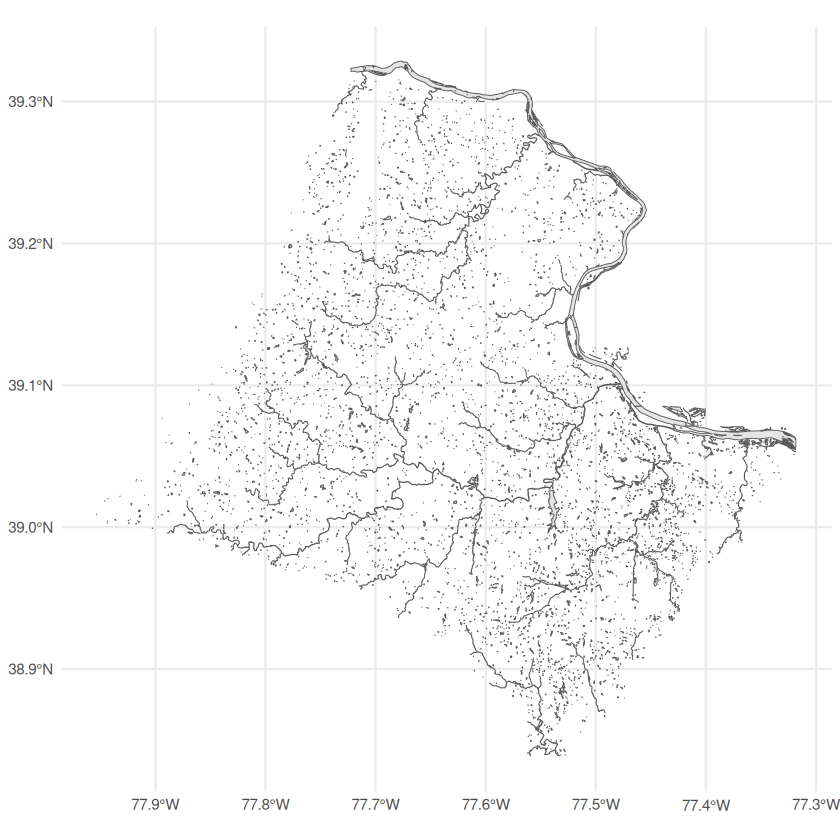

In [14]:
# Plot
library(ggplot2)

ggplot(water_bodies) +
  geom_sf() +
  theme_minimal()


In [15]:
# Convert points (latitude and longitude of data centers) to spatial features using st_as_sf()
data_centers_sf <- st_as_sf(
  data_centers_clean,
  coords = c("long", "lat"), # replace with your column names
  crs = 4326   # WGS84 lat/lon
)

In [16]:
# Check coordinate reference system (CRS) of both layers

st_crs(water_bodies)
st_crs(data_centers_sf)  
st_crs(boundary)

# PSG:4326 is WGS 84 so no need to transform using the st_transform() function


Coordinate Reference System:
  User input: WGS 84 
  wkt:
GEOGCRS["WGS 84",
    DATUM["World Geodetic System 1984",
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic latitude (Lat)",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433]],
        AXIS["geodetic longitude (Lon)",east,
            ORDER[2],
            ANGLEUNIT["degree",0.0174532925199433]],
    ID["EPSG",4326]]

Coordinate Reference System:
  User input: EPSG:4326 
  wkt:
GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER["World Geodetic System 1984 (G1674)"],
        MEMBER["World Geodetic System 1984 (G1762)"],
        MEMBER["World Geodetic System 1984 (G2139)"],
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]],
        ENSEMBLEACCURACY[2.0]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic latitude (Lat)",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433]],
        AXIS["geodetic longitude (Lon)",east,
            ORDER[2],
            ANGLEUNIT["degree",0.0174532925199433]],
    USAGE[
        SCOPE["Horizon

Coordinate Reference System:
  User input: WGS 84 
  wkt:
GEOGCRS["WGS 84",
    DATUM["World Geodetic System 1984",
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic latitude (Lat)",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433]],
        AXIS["geodetic longitude (Lon)",east,
            ORDER[2],
            ANGLEUNIT["degree",0.0174532925199433]],
    ID["EPSG",4326]]

In [17]:
# Load the Loundoun boundary geojson file from local data

boundary <- st_read("/home/user/Capstone/data_center_research_r/data/raw_data/Loudoun_County_Boundary.geojson")


Reading layer `Loudoun_County_Boundary' from data source 
  `/home/user/Capstone/data_center_research_r/data/raw_data/Loudoun_County_Boundary.geojson' 
  using driver `GeoJSON'
Simple feature collection with 1 feature and 6 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -77.9622 ymin: 38.84621 xmax: -77.32831 ymax: 39.3246
Geodetic CRS:  WGS 84


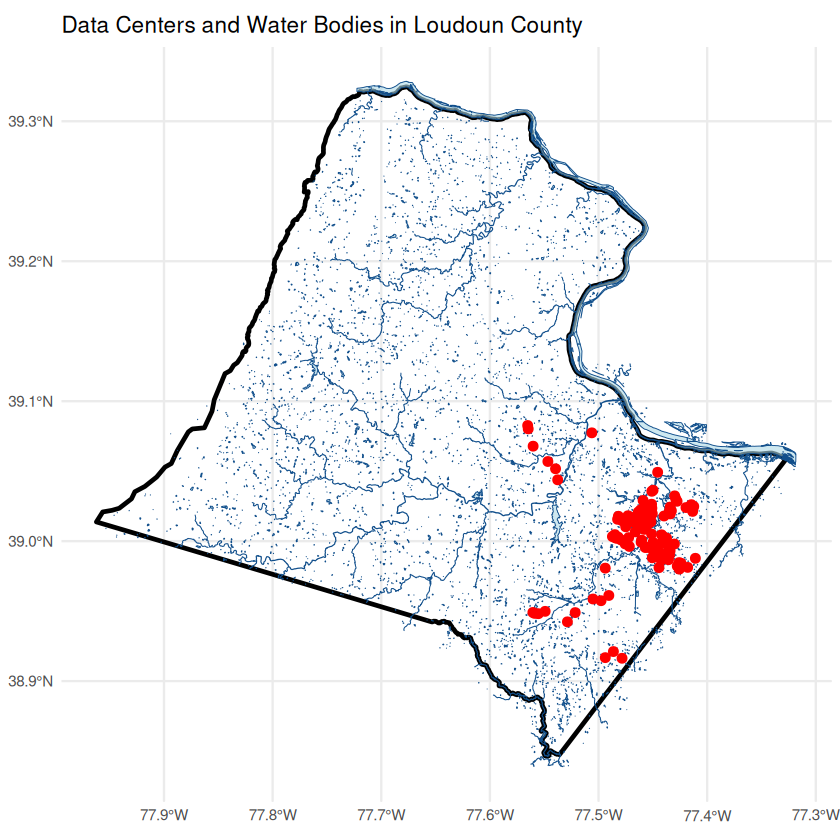

In [18]:
# Plot and overlay the boundary, water_bodies and data_centers layers

library(ggplot2)

ggplot() +
  # Loudoun County outline
  geom_sf(
    data = boundary,
    fill = NA,
    color = "black",
    linewidth = 1
  ) +
  # Water bodies
  geom_sf(
    data = water_bodies,
    fill = "lightblue",
    color = "dodgerblue4",
    alpha = 0.6
  ) +
  # Data centers
  geom_sf(
    data = data_centers_sf,
    color = "red",
    size = 2
  ) +
  theme_minimal() +
  labs(
    title = "Data Centers and Water Bodies in Loudoun County"
  )


In [19]:
# Lock the plot to the county boandaries

#ggplot() +
 # geom_sf(data = boundary, fill = NA, color = "black") +
  #geom_sf(data = water_bodies, fill = "lightblue", alpha = 0.6) +
  #geom_sf(data = data_centers_sf, color = "red", size = 2) +
  #coord_sf(
   # xlim = st_bbox(boundary)[c("xmin", "xmax")],
   # ylim = st_bbox(boundary)[c("ymin", "ymax")]
 # ) +
 # theme_minimal()


In [20]:
library(units)

# Calculate distance from each data center to nearest water body in feet

crs_feet <- 2283  # NAD83 / Virginia North (US feet)

data_centers_sf <- st_transform(data_centers_sf, crs_feet)
water_bodies    <- st_transform(water_bodies, crs_feet)

#Calculate distances

dist_matrix <- st_distance(data_centers_sf, water_bodies)

data_centers_sf$min_dist_ft <- apply(dist_matrix, 1, min) # Compute minimum distance of water bodies per data center 

#Prepare matrice
#Check columns
names(data_centers_sf)
names(water_bodies)

# Assign data center names to rows
rownames(dist_matrix) <- data_centers_sf$name

#Assign water enter names to columns
colnames(dist_matrix) <- water_bodies$WA_TYPE

# View
# Drop units for readability
dist_matrix <- drop_units(dist_matrix)

# View the first few rows
dist_matrix[1:6, ]   # first 6 data centers, all water bodies





udunits database from /usr/share/xml/udunits/udunits2.xml



[1] "object_id"         "locality"          "name"             
 [4] "street_address"    "owner_applicant"   "acres"            
 [7] "building_sq_ft"    "construction_type" "build_status"     
[10] "geometry"          "min_dist_ft"

[1] "OBJECTID"     "WA_WELEV"     "WA_SOURCE"    "WA_UPD_DATE"  "WA_TYPE"     
 [6] "Shape_Length" "Shape_Area"   "WA_LOUD_ID"   "agstype"      "geometry"

,1,7,7,7,7,11,11,4,4,4,⋯,1,1,10,4,1,1,1,4,10,1
NV-8 CYRUSONE,124674.6,126912.4,117865.5,129809.2,121769.5,136576.1,122812.9,130895.6,118777.8,120473.1,⋯,118525.9,82996.59,52521.66,74188.49,95377.89,96122.47,93906.48,100583.46,26649.76,76101.71
CYXTERA DC2 COLOCATION,124200.4,126365.0,117368.2,129310.3,121232.7,136047.7,122348.9,130456.2,118259.4,119957.4,⋯,117958.6,82530.74,51947.86,73693.63,95033.82,95835.56,93588.28,100252.74,26038.63,75848.39
MARIES TECH PARK LLC,122730.4,125059.9,115945.2,127890.3,119900.6,134694.6,120859.6,128923.4,116883.1,118574.8,⋯,116708.5,81045.93,50723.35,72267.11,93368.37,94113.11,91895.13,98572.59,24953.05,74099.18
45845 NOKES BLVD,123619.6,125825.6,116798.7,128741.7,120686.3,135496.0,121763.5,129861.0,117701.6,119398.0,⋯,117433.8,81946.06,51428.01,73122.69,94411.96,95205.37,92962.01,99628.49,25552.80,75215.56
C1 NORTHERN VA - STERLING I-III,123208.3,125317.1,116357.3,128298.1,120192.2,135013.0,121365.6,129494.5,117232.1,118932.2,⋯,116898.2,81546.85,50884.53,72685.76,94166.52,95029.95,92748.55,99399.29,24956.81,75082.32
CYXTERA COLOCATION,123978.2,126064.6,117122.0,129062.4,120944.1,135768.0,122137.3,130269.3,117990.7,119691.7,⋯,117636.0,82318.53,51620.51,73451.68,94940.77,95795.57,93519.56,100172.06,25670.98,75839.93


In [21]:
#Import JSON file on air sites emissions in Virginia

#air_site_emissions <- #st_read("/home/user/Capstone/data_center_research_r/data/raw_data/active_air_sites.geojson")

#active_air_sites <- st_read 
("/home/user/Capstone/data_center_research_r/data/raw_data/air_sites_emissions_2024_totals.geojson")



[1] "/home/user/Capstone/data_center_research_r/data/raw_data/air_sites_emissions_2024_totals.geojson"

In [22]:
# Import CSV file on air_sites in Virginia
air_sites <- read.csv ("/home/user/Capstone/data_center_research/data/processed/active_air_sites.csv")

# Get the dimensions of the dataframe
dim(air_sites)

# Examine the variables of the dataset
names(air_sites)

# Examine the structure of the dataset
str(air_sites)

[1] 3706   18

[1] "X"                     "Y"                     "OBJECTID"             
 [4] "PLA_ID"                "PLA_REG_NUM"           "PLA_NAME"             
 [7] "FAC_L_ADDR_1"          "FAC_L_CITY"            "FAC_L_STATE"          
[10] "FAC_L_ZIP5"            "PLA_NAC_CODE_PRIMARY"  "PLA_PRINCIPAL_PRODUCT"
[13] "PLA_ICIS_ID"           "PLA_DESC"              "PCL_STATE_DESC"       
[16] "AIR_OP_STATUS"         "PCL_FED_DESC"          "Data_Disclaimer"

'data.frame':	3706 obs. of  18 variables:
 $ X                    : num  -8620206 -8629624 -8615785 -8662972 -8737022 ...
 $ Y                    : num  4539851 4524848 4481733 4481398 4445000 ...
 $ OBJECTID             : int  1 2 3 4 5 6 7 8 9 10 ...
 $ PLA_ID               : int  34376 34441 34087 40193 34976 34942 34551 40969 39695 40330 ...
 $ PLA_REG_NUM          : int  51065 50957 50831 52155 30961 30926 30326 81617 73316 73448 ...
 $ PLA_NAME             : chr  "Concrete Pipe and Precast LLC - Ashland Plant" "Allied Animal Hospital" "Solstice Advanced Materials US Inc - South Chesterfield" "Vulcan Construction Materials LLC - Amelia Quarry" ...
 $ FAC_L_ADDR_1         : chr  "11352 Virginia Precast Rd" "7209 W Broad St" "15801 Woods Edge Rd" "6750 Richmond Rd" ...
 $ FAC_L_CITY           : chr  "Ashland" "Richmond" "Colonial Heights" "Amelia" ...
 $ FAC_L_STATE          : chr  "VA" "VA" "VA" "VA" ...
 $ FAC_L_ZIP5           : int  23005 23294 23834 23002 23947 23950 24592 22824

In [23]:
# Create new dataframe
air_sites_clean <- as.data.frame(air_sites)

# Rename variables
air_sites_clean <- air_sites_clean %>%
    rename(
      x = X,
      y = Y,  
      objectid = OBJECTID,
      id = PLA_ID,
      reg_num = PLA_REG_NUM,
      name = PLA_NAME,
      address = FAC_L_ADDR_1,
      city = FAC_L_CITY,
      state = FAC_L_STATE,
      zip = FAC_L_ZIP5,
      nac_code_primary = PLA_NAC_CODE_PRIMARY,
      principal_product = PLA_PRINCIPAL_PRODUCT,
      icis_id = PLA_ICIS_ID,
      desc = PLA_DESC,
      state_desc = PCL_STATE_DESC,
      air_op_status = AIR_OP_STATUS,
      fed_desc = PCL_FED_DESC,
      data_disclaimer = Data_Disclaimer
    )

# List the renames
names(air_sites_clean)

[1] "x"                 "y"                 "objectid"         
 [4] "id"                "reg_num"           "name"             
 [7] "address"           "city"              "state"            
[10] "zip"               "nac_code_primary"  "principal_product"
[13] "icis_id"           "desc"              "state_desc"       
[16] "air_op_status"     "fed_desc"          "data_disclaimer"

In [24]:
# List the categories within the "city" and "principal_product" categories
unique(air_sites_clean$city)
unique(air_sites_clean$principal_product)



[1] "Ashland"                                
  [2] "Richmond"                               
  [3] "Colonial Heights"                       
  [4] "Amelia"                                 
  [5] "Keysville"                              
  [6] "La Crosse"                              
  [7] "South Boston"                           
  [8] "Edinburg"                               
  [9] "Chantilly"                              
 [10] "Vienna"                                 
 [11] "Fairfax"                                
 [12] "Herndon"                                
 [13] "Leesburg"                               
 [14] "Arlington"                              
 [15] "Waverly"                                
 [16] "Prince George"                          
 [17] "Manakin Sabot"                          
 [18] "Tappahannock"                           
 [19] "Buckingham"                             
 [20] "Cumberland"                             
 [21] "Clarksville"                            
 [22] "Norfolk"                                
 [23] "Suffolk"                                
 [24] "Falmouth"                               
 [25] "Falls Church"                           
 [26] "Culpeper"                               
 [27] "Manassas"                               
 [28] "Dumfries"                               
 [29] "Springfield"                            
 [30] "Stafford"                               
 [31] "Centreville"                            
 [32] "Fredericksburg"                         
 [33] "Sterling"                               
 [34] "Orange"                                 
 [35] "Rustburg"                               
 [36] "Concord"                                
 [37] "Chester"                                
 [38] "Petersburg"                             
 [39] "Newport News"                           
 [40] "Front Royal"                            
 [41] "Big Rock"                               
 [42] "Galax"                                  
 [43] "Timberville"                            
 [44] "Harrisonburg"                           
 [45] "Hinton"                                 
 [46] "Louisa"                                 
 [47] "Charlottesville"                        
 [48] "Columbia"                               
 [49] "Chase City"                             
 [50] "Scottsburg"                             
 [51] "Lawrenceville"                          
 [52] "Jarratt"                                
 [53] "Rockville"                              
 [54] "Little Plymouth"                        
 [55] "Yorktown"                               
 [56] "Hampton"                                
 [57] "Annandale"                              
 [58] "Appalachia"                             
 [59] "Alexandria"                             
 [60] "Spotsylvania"                           
 [61] "Big Stone Gap"                          
 [62] "Norton"                                 
 [63] "Winchester"                             
 [64] "Blairs"                                 
 [65] "Duffield"                               
 [66] "Salem"                                  
 [67] "Zion Crossroads"                        
 [68] "Remington"                              
 [69] "Portsmouth"                             
 [70] "Kilmarnock"                             
 [71] "Charles City"                           
 [72] "Lebanon"                                
 [73] "Monterey"                               
 [74] "Ashburn"                                
 [75] "Virginia Beach"                         
 [76] "Williamsburg"                           
 [77] "Glen Allen"                             
 [78] "Sandston"                               
 [79] "Austinville"                            
 [80] "Chilhowie"                              
 [81] "Quantico"                               
 [82] "Abingdon"                               
 [83] "Glade Spring"                           
 [84] "Stuart"    

[1] "concrete"                                                               
   [2] "animal hospital"                                                        
   [3] "polyolefin fiber"                                                       
   [4] "Stone quarrying, crushing"                                              
   [5] "wood furn comp manuf"                                                   
   [6] "structural steel"                                                       
   [7] "transformers"                                                           
   [8] "biodiesel"                                                              
   [9] "cellular telecom services"                                              
  [10] "Auto Body Shop"                                                         
  [11] "bulk terminal"                                                          
  [12] "Data Center"                                                            
  [13] "Natural gas transmission"                                               
  [14] "training"                                                               
  [15] "rr service"                                                             
  [16] "ba concrte"                                                             
  [17] "CH4 supplier"                                                           
  [18] "ng compressors"                                                         
  [19] "Wood Pellets"                                                           
  [20] "Hogs"                                                                   
  [21] ""                                                                       
  [22] "crematory services"                                                     
  [23] "funeral services"                                                       
  [24] "bulk plt"                                                               
  [25] "emergency generators"                                                   
  [26] "bread"                                                                  
  [27] "autobody repair"                                                        
  [28] "iron foundry"                                                           
  [29] "information service"                                                    
  [30] "asphalt"                                                                
  [31] "crushed stone"                                                          
  [32] "electricity"                                                            
  [33] "batch concrete"                                                         
  [34] "wheat flour"                                                            
  [35] "drycleaner"                                                             
  [36] "waste disposal"                                                         
  [37] "crshd stne"                                                             
  [38] "plastic film"                                                           
  [39] "dry cleaners"                                                           
  [40] "dry-to-dry"                                                             
  [41] "medical care"                                                           
  [42] "coal prep"                                                              
  [43] "wood household furniture"                                               
  [44] "poultry rendering"                                                      
  [45] "feeds"                                                                  
  [46] "poultry"                                                                
  [47] "vermiculite"                                                            
  [48] "vermiculite ore"                                                        
  [49] "bulk petro"                                                             
  [50] "petroleum products"       

In [25]:
# Select only relevant columns and rows
air_sites_clean <- air_sites_clean %>%
    select(name, address, city, principal_product, icis_id) %>%
    filter(city %in% c('Leesburg', 'Ashburn', 'Sterling', 'Aldie', 'Purcellville', 'Fairfax')) %>%
    filter(principal_product %in% c('Data Center', 'data center', 'Data center'))

air_sites_clean

name,address,city,principal_product,icis_id
<chr>,<chr>,<chr>,<chr>,<chr>
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820
"Zayo Group, LLC",21635 Red Rum Dr,Ashburn,Data Center,VA0000005110701009
VA1 Data Center,44664 Guilford Dr,Ashburn,Data Center,VA0000005110701039
"Equinix, LLC - Ashburn",21551 Beaumeade Cir,Ashburn,Data Center,VA0000005110701036
"Verizon Business Network Services, Inc.",22001 Loudoun County Pkwy,Ashburn,Data Center,VA0000005110700141
"SI NVA01 ABS, LLC",22080 Pacific Blvd,Sterling,Data Center,VA0000005110701057
"Amazon Data Services, Inc. IAD 50 IAD 60 IAD-71 IAD-78 IAD-79 IAD-80",21271 Smith Switch Rd,Ashburn,Data Center,VA0000005110701047
CyrusOne Northern Virginia Data Center - Shaw Road,511 Shaw Road,Sterling,Data Center,VA0000005110774109
"Amazon Data Services, Inc. IAD-62/68/81/83/93/609/614",42911 Arcola Road,Sterling,Data Center,VA0000005110774085


In [26]:
list.files("/home/user/Capstone/data_center_research_r/data/processed/")

# Import CSV file on air_emissions for the year 2024 in Virginia. The file is directly in the working directory.

air_sites_emissions <- read.csv("home/user/Capstone/data_center_research/data/processed/air_sites_emissions.csv")


# Get the dimensions of the dataframe
dim(air_sites_emissions)

# Examine the variables ofthe dataset
names(air_sites_emissions)

# Examine the structure of the dataset
str(air_sites_emissions)

[1] "active_air_sites.csv"                
[2] "air_sites_emissions.csv"             
[3] "data_centers_runoff_calculations.csv"
[4] "PEC_table-1.csv"                     
[5] "README.txt"

[1] 17780     9

[1] "OBJECTID"           "EY_PLA_ID"          "EMISSIONSYEAR"     
[4] "CPL_SHORT_NAME"     "EMISSION_VALUE"     "PLA_ICIS_ID"       
[7] "PLA_NAME"           "PLA_REG_NUM"        "CPL_POLLUTANT_NAME"

'data.frame':	17780 obs. of  9 variables:
 $ OBJECTID          : int  1 2 3 4 5 6 7 8 9 10 ...
 $ EY_PLA_ID         : int  44670 44670 44670 44671 44671 44671 44669 44669 44669 44691 ...
 $ EMISSIONSYEAR     : int  2024 2024 2024 2024 2024 2024 2024 2024 2024 2024 ...
 $ CPL_SHORT_NAME    : chr  "PM" "PM 10" "PM 2.5" "PM" ...
 $ EMISSION_VALUE    : num  0 0 0 0 0 0 0 0 0 0 ...
 $ PLA_ICIS_ID       : chr  "VA0000005108553113" "VA0000005108553113" "VA0000005108553113" "VA0000005108553114" ...
 $ PLA_NAME          : chr  "James River Equipment - Ashland - Portable 53113" "James River Equipment - Ashland - Portable 53113" "James River Equipment - Ashland - Portable 53113" "James River Equipment - Ashland - Portable 53114" ...
 $ PLA_REG_NUM       : int  53113 53113 53113 53114 53114 53114 53112 53112 53112 53131 ...
 $ CPL_POLLUTANT_NAME: chr  "Particulate Matter" "Particulate Matter 10" "Particulate Matter 2.5" "Particulate Matter" ...


In [27]:
# Rename variables
air_sites_emissions <- air_sites_emissions %>%
    rename(
      objectid = OBJECTID,
      id = EY_PLA_ID,
      emissionsyear = EMISSIONSYEAR,
      short_name = CPL_SHORT_NAME,
      emission_value = EMISSION_VALUE,
      icis_id = PLA_ICIS_ID,
      name = PLA_NAME,
      reg_num = PLA_REG_NUM,
      pollutant_name = CPL_POLLUTANT_NAME
    )

# List the renames
names(air_sites_emissions)

[1] "objectid"       "id"             "emissionsyear"  "short_name"    
[5] "emission_value" "icis_id"        "name"           "reg_num"       
[9] "pollutant_name"

In [28]:
# Select only relevant columns and rows
air_sites_emissions_clean <- air_sites_emissions %>%
    select(emissionsyear, emission_value, icis_id, pollutant_name)

air_sites_emissions_clean


emissionsyear,emission_value,icis_id,pollutant_name
<int>,<dbl>,<chr>,<chr>
2024,0.000000,VA0000005108553113,Particulate Matter
2024,0.000000,VA0000005108553113,Particulate Matter 10
2024,0.000000,VA0000005108553113,Particulate Matter 2.5
2024,0.000000,VA0000005108553114,Particulate Matter
2024,0.000000,VA0000005108553114,Particulate Matter 10
2024,0.000000,VA0000005108553114,Particulate Matter 2.5
2024,0.000000,VA0000005108553112,Particulate Matter
2024,0.000000,VA0000005108553112,Particulate Matter 10
2024,0.000000,VA0000005108553112,Particulate Matter 2.5


In [29]:
# Join air_sites_cleanand air_sites_emissions_clean

air_emissions_joined <- left_join(x = air_sites_clean, y = air_sites_emissions_clean, by = "icis_id")
air_emissions_joined

air_emissions_joined <- air_emissions_joined[complete.cases(air_emissions_joined), ]
air_emissions_joined

name,address,city,principal_product,icis_id,emissionsyear,emission_value,pollutant_name
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.55391400,Nitrogen Oxide
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.02376000,Particulate Matter
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.02904000,Volatile Organic Compounds
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.03062400,Sulfur Dioxide
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.10560000,Carbon Monoxide
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.02376000,Particulate Matter 10
"Zayo Group, LLC",21635 Red Rum Dr,Ashburn,Data Center,VA0000005110701009,2024,5.85404600,Nitrogen Oxide
"Zayo Group, LLC",21635 Red Rum Dr,Ashburn,Data Center,VA0000005110701009,2024,0.11783700,Volatile Organic Compounds
"Zayo Group, LLC",21635 Red Rum Dr,Ashburn,Data Center,VA0000005110701009,2024,0.00562105,Sulfur Dioxide


,name,address,city,principal_product,icis_id,emissionsyear,emission_value,pollutant_name
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>
1,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.55391400,Nitrogen Oxide
2,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.02376000,Particulate Matter
3,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.02904000,Volatile Organic Compounds
4,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.03062400,Sulfur Dioxide
5,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.10560000,Carbon Monoxide
6,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.02376000,Particulate Matter 10
7,"Zayo Group, LLC",21635 Red Rum Dr,Ashburn,Data Center,VA0000005110701009,2024,5.85404600,Nitrogen Oxide
8,"Zayo Group, LLC",21635 Red Rum Dr,Ashburn,Data Center,VA0000005110701009,2024,0.11783700,Volatile Organic Compounds
9,"Zayo Group, LLC",21635 Red Rum Dr,Ashburn,Data Center,VA0000005110701009,2024,0.00562105,Sulfur Dioxide


In [30]:

# Get the dimensions of the dataframe
dim(air_emissions_joined)

# Examine the variables ofthe dataset
names(air_emissions_joined)

# Examine the structure of the dataset
str(air_emissions_joined)

# Examine unque number of data centers
unique(air_emissions_joined$name)
length(unique(air_emissions_joined$name))
unique(air_emissions_joined$address)


[1] 240   8

[1] "name"              "address"           "city"             
[4] "principal_product" "icis_id"           "emissionsyear"    
[7] "emission_value"    "pollutant_name"

'data.frame':	240 obs. of  8 variables:
 $ name             : chr  "Equinix LLC" "Equinix LLC" "Equinix LLC" "Equinix LLC" ...
 $ address          : chr  "44470 Chilum Pl" "44470 Chilum Pl" "44470 Chilum Pl" "44470 Chilum Pl" ...
 $ city             : chr  "Ashburn" "Ashburn" "Ashburn" "Ashburn" ...
 $ principal_product: chr  "data center" "data center" "data center" "data center" ...
 $ icis_id          : chr  "VA0000005110700820" "VA0000005110700820" "VA0000005110700820" "VA0000005110700820" ...
 $ emissionsyear    : int  2024 2024 2024 2024 2024 2024 2024 2024 2024 2024 ...
 $ emission_value   : num  0.5539 0.0238 0.029 0.0306 0.1056 ...
 $ pollutant_name   : chr  "Nitrogen Oxide" "Particulate Matter" "Volatile Organic Compounds" "Sulfur Dioxide" ...


[1] "Equinix LLC"                                                                           
 [2] "Zayo Group, LLC"                                                                       
 [3] "VA1 Data Center"                                                                       
 [4] "Equinix, LLC - Ashburn"                                                                
 [5] "Verizon Business Network Services, Inc."                                               
 [6] "SI NVA01 ABS, LLC"                                                                     
 [7] "Amazon Data Services, Inc. IAD 50 IAD 60 IAD-71  IAD-78 IAD-79 IAD-80"                 
 [8] "CyrusOne Northern Virginia Data Center - Shaw Road"                                    
 [9] "Amazon Data Services, Inc. IAD-62/68/81/83/93/609/614"                                 
[10] "NTT Global Data Centers Americas, Inc. - VA2 Data Center"                              
[11] "NTT Global Data Centers Americas, Inc."                                                
[12] "Vantage Data Centers VA11, VA12, VA13, VA14, & VA15"                                   
[13] "Amazon Data Services Inc IAD-120/121/122"                                              
[14] "Digital Western Lands LLC"                                                             
[15] "Cologix ASH1"                                                                          
[16] "Iskander (LC-1A) Jamshid (LC-1B) Kaveh (LC2) Lohrasp Ventures (LC3)"                   
[17] "Amazon Data Services, Inc. IAD-140/141/143"                                            
[18] "Darab Ventures One, Two, Six LLC"                                                      
[19] "QTS Investment Properties Ashburn LLC"                                                 
[20] "Vantage Data Centers VA2 LLC"                                                          
[21] "Aligned Energy Data Centers (Ashburn), LLC"                                            
[22] "CyrusOne Sterling IX/X/XI"                                                             
[23] "Aligned Data Centers IAD03"                                                            
[24] "Amazon Data Services, Inc.  IAD-90 IAD-91 IAD-92"                                      
[25] "Digital Realty (Digital Loudoun 3 & 4, LLC)"                                           
[26] "Digital Realty - Sterling Premiere LLC"                                                
[27] "Amazon Data Services, Inc. IAD-51 IAD-56 IAD-88  IAD-89"                               
[28] "QTS LLC - Ashburn-Shellhorn Data Center"                                               
[29] "Amazon Data Services, Inc."                                                            
[30] "Yondr Data Center"                                                                     
[31] "Equinix LLC - DC 13"                                                                   
[32] "Amazon Data Services Inc - IAD-163/164/174"                                            
[33] "Hayden Technologies, LLC."                                                             
[34] "CyrusOne Northern Virginia Data Center - Maries Road"                                  
[35] "Amazon Data Services, Inc. IAD-57 IAD-58"                                              
[36] "Sentinel Ashburn Nexus"                                                                
[37] "Wheeler Data Center"                                                                   
[38] "Microsoft Corporation – Leesburg Data Center (IAD01-02-03-04-05)"                      
[39] "Amazon Data Services Inc IAD-161, IAD-162, IAD-606, IAD-285, IAD-286, IAD-299, IAD-611"
[40] "Amazon Data Services, Inc. IAD-114 IAD-115"                                            
[41] "Microsoft Blue Ridge (IAD11-12-13) Data Center"                                        
[42] "Amazon Data Services, Inc. IAD-144  IAD-145"                                           
[43] "Equinix LLC (DC-21/DC-22)"                     

[1] 44

[1] "44470 Chilum Pl"              "21635 Red Rum Dr"            
 [3] "44664 Guilford Dr"            "21551 Beaumeade Cir"         
 [5] "22001 Loudoun County Pkwy"    "22080 Pacific Blvd"          
 [7] "21271 Smith Switch Rd"        "511 Shaw Road"               
 [9] "42911 Arcola Road"            "44610 Guilford Drive"        
[11] "44245 Gigabit Plaza"          "45194 Vantage Data Plaza"    
[13] "23825 Erins Run Drive"        "43704 Efficiency Drive"      
[15] "21745 Beaumeade Circle"       "21955 Loudoun County Parkway"
[17] "22890 Platform Plaza"         "22210 Loudoun County Parkway"
[19] "22271 Broderick Drive"        "22435 Glenn Drive"           
[21] "21890 Uunet Drive"            "43290 Old Ox Road"           
[23] "Relocation Drive"             "45900 Pathfinder Way"        
[25] "44274 Roundtable Plaza"       "22588 Relocation Drive"      
[27] "45220 Prologis Plaza"         "22291 Shellhorn Road"        
[29] "22370 & 22420 Kipper Drive"   "24171 Youngwood Lane"        
[31] "22001 Loudoun County Parkway" "21099 Atlantic Boulevard"    
[33] "20491 Goose Landing Ln"       "45905 Maries Road"           
[35] "28755 Relocation Drive"       "22262 Cloud Plaza"           
[37] "42575 Arcola Blvd"            "19935 Sycolin Road"          
[39] "44254 Import Plaza"           "20945 Loudoun County Parkway"
[41] "24282 Quail Ridge Lane"       "22945 International Drive"   
[43] "22175 Beaumeade Circle"       "45781 Maries Road"

In [31]:
#Create a table of Cities
table(air_emissions_joined$city)

table(air_emissions_joined$emission_value)

# List the categories within the "emission_vale" categories
unique(air_emissions_joined$emission_value)

# Length of "emission_value" to determine count of unique value
length(unique(air_emissions_joined$emission_value))



   Aldie  Ashburn Leesburg Sterling 
      10       96       11      123 


           0    3.475e-07   1.5806e-05  2.22705e-05  2.39727e-05  7.43294e-05 
           5            1            1            1            2            1 
0.0001208562 0.0002580319  0.000385832     0.000508     0.000586   0.00060735 
           1            1            1            1            1            1 
  0.00142367    0.0014787  0.001667479  0.001680592  0.002490083    0.0040031 
           1            1            1            1            1            1 
  0.00414782 0.0046158488     0.005236 0.0053147355   0.00562105    0.0057135 
           1            1            1            1            1            1 
   0.0063825  0.006834946  0.006999097      0.00977  0.011537195      0.01171 
           1            1            1            2            1            1 
    0.015486     0.017355    0.0189842    0.0197775    0.0197955   0.02163284 
           1            2            1            1            1            2 
    0.021682      0.02376      0.02783      0.02904

[1] 5.539140e-01 2.376000e-02 2.904000e-02 3.062400e-02 1.056000e-01
  [6] 5.854046e+00 1.178370e-01 5.621050e-03 9.479845e-01 9.315550e-02
 [11] 4.816920e-01 2.168200e-02 5.860000e-04 1.977750e-02 5.713500e-03
 [16] 8.973641e+00 5.384900e-02 3.155650e-01 5.236000e-03 1.013700e+00
 [21] 1.360040e-01 1.377450e-01 3.121300e+00 2.029300e-01 1.080380e+00
 [26] 3.629350e-02 5.080000e-04 4.236853e-01 3.124050e-02 6.163753e+00
 [31] 6.978068e-01 6.834946e-03 3.291583e+00 2.376689e-01 4.396775e+00
 [36] 9.031750e-02 7.106300e-01 2.790618e+00 1.979550e-02 7.607890e-02
 [41] 1.580600e-05 2.300130e-01 2.163284e-02 1.157445e+00 1.548600e-02
 [46] 7.716300e-02 1.735500e-02 5.269006e+00 4.473512e-01 2.559994e+00
 [51] 2.557434e-01 5.503295e+00 3.998521e-01 4.003100e-03 2.601886e+00
 [56] 2.202221e-01 1.576004e+00 1.768010e-01 1.423670e-03 8.528940e-01
 [61] 5.797400e-02 1.639676e+00 7.188920e-01 1.680592e-03 1.211386e+00
 [66] 1.341000e-01 3.858320e-04 2.227050e-05 7.432940e-05 3.475000e-07
 [71] 1.208562e-04 2.397270e-05 8.560170e+00 2.152740e-01 6.382500e-03
 [76] 4.474950e+00 3.024300e-01 5.805552e+00 3.905200e-02 6.596393e-01
 [81] 5.314735e-03 2.747119e+00 2.036053e-01 9.372473e+00 1.495478e+00
 [86] 2.764766e+00 4.581387e-01 3.308210e+00 6.460850e-02 1.377905e-01
 [91] 6.073500e-04 5.035858e-01 2.195393e+01 1.512493e+01 1.174004e+01
 [96] 5.097790e+00 1.405168e+01 1.513959e+01 1.814347e+01 4.802400e-01
[101] 2.835263e+00 2.514930e-01 4.118945e+00 4.235050e-01 1.138490e+00
[106] 1.906950e-01 0.000000e+00 4.709693e+00 5.270775e-01 2.516370e+00
[111] 1.700250e-01 7.416651e+00 4.881365e-01 2.789948e+00 3.305670e-01
[116] 2.585150e-01 1.171000e-02 9.071500e-02 9.770000e-03 1.329654e+01
[121] 1.020930e+00 1.153720e-02 4.816695e+00 3.444715e-01 3.431340e-01
[126] 7.495096e+00 1.443908e+00 6.999097e-03 2.347729e+00 4.656880e-01
[131] 4.523410e+00 5.013310e-01 4.147820e-03 2.416840e+00 1.616670e-01
[136] 8.822320e+00 1.329835e+00 2.400190e+00 3.567850e-01 1.493375e+00
[141] 6.533250e-02 3.527955e-01 2.654631e+00 2.898145e-01 1.045459e+00
[146] 8.890200e-02 4.029370e-01 1.898420e-02 2.580319e-04 1.551755e-01
[151] 3.121665e+00 1.881665e+00 1.014829e+01 3.130950e-01 1.760304e+00
[156] 1.327333e-01 1.962390e+00 2.524206e-01 1.478700e-03 1.044426e+00
[161] 1.121272e-01 4.688543e+00 1.376158e-01 1.332192e-01 6.685762e-01
[166] 7.907625e-02 5.151000e-02 6.054450e-01 4.386700e-02 2.090050e-01
[171] 3.737832e+00 6.162360e+00 4.126250e-01 2.346145e+00 1.959600e-01
[176] 4.515861e+00 5.163191e-01 4.615849e-03 2.411737e+00 1.803065e-01
[181] 1.818527e+00 2.026983e-01 1.667479e-03 9.715730e-01 6.579418e-02
[186] 1.127420e+00 7.537000e-02 4.289600e-01 2.783000e-02 5.347923e+00
[191] 5.937263e-01 2.490083e-03 2.952545e+00 1.911695e-01 3.101082e+00
[196] 2.597100e-01 4.086565e-01 1.524735e-01 3.614850e+00 4.045500e-01
[201] 1.944450e+00 1.305000e-01

[1] 202

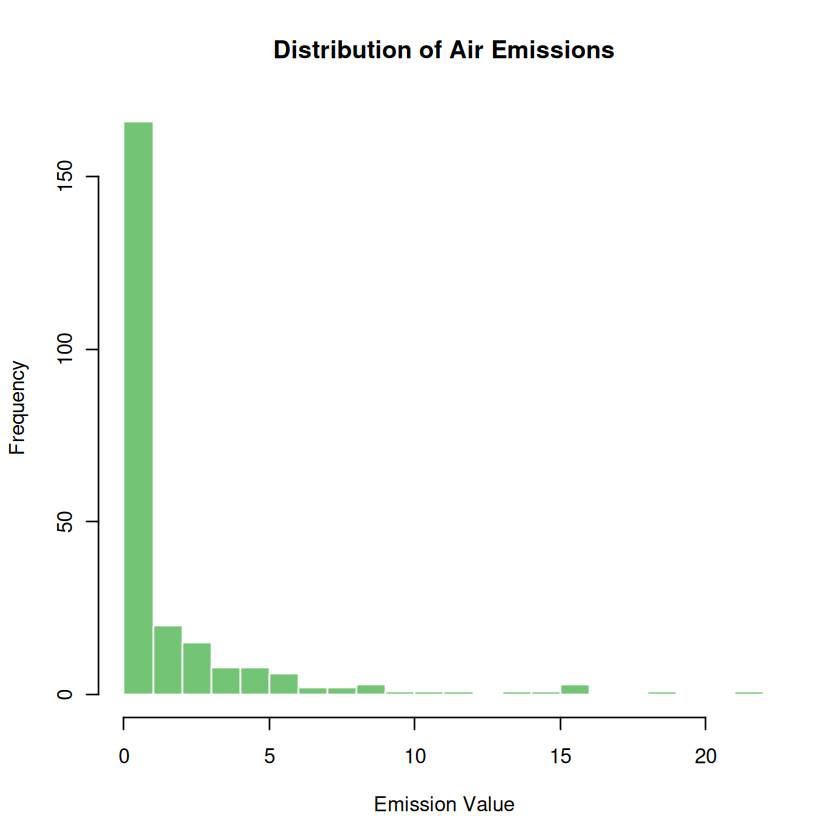

In [32]:
# histogram of emission values

hist(
  air_emissions_joined$emission_value,
  col = "#74c476",
  border = "white",
  breaks = 20,
  main = "Distribution of Air Emissions",
  xlab = "Emission Value"
)

# Distribution is right-skewed

[1] 1.637801

[1] 0.2557434

0%         25%         50%         75%        100% 
 0.00000000  0.06294987  0.25574345  1.59192200 21.95392582

[1]  0  2  4  6  8 10 12 14 16 18 20 22

[1] 186  23  14   4   4   2   1   4   0   1   1

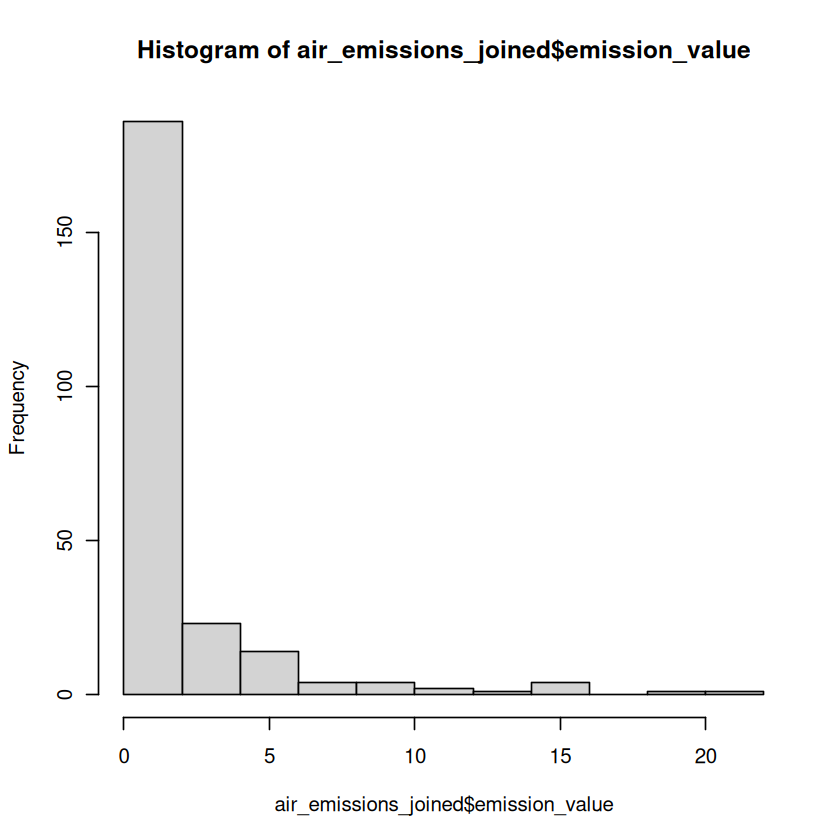

In [33]:
# Mean of "emissionvalue"
mean(air_emissions_joined$emission_value)

# Median of "emission_value"
median(air_emissions_joined$emission_value)

# Quantile of "emission_value"
quantile(air_emissions_joined$emission_value)


# to see how the histogram was made
hist2 <- hist(air_emissions_joined$emission_value)
hist2$breaks
hist2$counts

In [34]:
# Identify the outlier

air_emissions_joined$name[air_emissions_joined$emission_value>20]

[1] "Vantage Data Centers VA2 LLC"

In [35]:
# Analyze how many data centers are emitting each pollutant (Note:  data centers emit more than one pollutant)

air_emissions_joined %>%
  filter(principal_product %in% c('Data Center', 'data center', 'Data center')) %>%
  group_by(pollutant_name) %>%
  summarise(num_data_centers = n()) # num_data_centers is a new column name

pollutant_name,num_data_centers
<chr>,<int>
Carbon Monoxide,44
Nitrogen Oxide,44
Particulate Matter,7
Particulate Matter 10,40
Particulate Matter 2.5,38
Sulfur Dioxide,25
Volatile Organic Compounds,42


In [36]:
# Find index of nearest water body polygon for each data center point
#nearest_idx <- st_nearest_feature(data_center, water_bodies)

# Compute distance from each data center point to its nearest water body polygon
#nearest_dist <- st_distance(
#  data_center,
#  water_bodies[nearest_idx, ],
#  by_element = TRUE
#)

# Bind results back onto data_center
#data_center_final <- data_center %>%
 # mutate(
 #   nearest_water_idx  = nearest_idx,
 #   nearest_water_name   = water_bodies$name[nearest_idx],   
 #   dist_to_water_m    = nearest_dist 
 # )

In [37]:

# Standarize the addresses in the air_emissions_joined and data_centers_clean (PEC) datasets

air_emissions_joined <- air_emissions_joined %>%
  mutate(address_clean = address %>%
           str_to_lower() %>%
          str_trim() %>%
          str_replace_all("\\.", "") %>%
          str_replace_all(" pl$", " plaza") %>%
          str_replace_all(" dr$", " drive") %>%
          str_replace_all(" rd$", " road") %>%
          str_replace_all(" ln$", " lane") %>%
          str_replace_all(" cir$", " circle") %>%
          str_replace_all(" pkwy$", " parkway"))

data_centers_clean <- data_centers_clean %>%
  mutate(address_clean = street_address %>%
          str_to_lower() %>%
          str_trim() %>%
          str_replace_all("\\.", "") %>%
          str_replace_all(" pl$", " plaza") %>%
          str_replace_all(" dr$", " drive") %>%
          str_replace_all(" rd$", " road") %>%
          str_replace_all(" ln$", " lane") %>%
          str_replace_all(" cir$", " circle") %>%
          str_replace_all(" pkwy$", " parkway"))

# Manually add in missing address

air_emissions_joined <- air_emissions_joined %>%
  mutate(address_clean = address_clean %>%
           str_replace_all(" plz$", " plaza") %>%
           str_replace_all("round table", "roundtable"))

data_centers_clean <- data_centers_clean %>%
  mutate(address_clean = address_clean %>%
           str_replace_all(" plz$", " plaza") %>%
           str_replace_all("round table", "roundtable"))

data_centers_clean <- data_centers_clean %>%
 mutate(address_clean = case_when(
  address_clean == "45900n pathfinder plaza" ~ "45900 pathfinder way",
   TRUE ~ address_clean
  ))

# Standardize Pathfinder address in emissions dataset
air_emissions_joined <- air_emissions_joined %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^45900") &
    str_detect(address_clean, "pathfinder") ~ "45900 pathfinder plaza",
    TRUE ~ address_clean
  ))

# Standardize Pathfinder address in data centers dataset
data_centers_clean <- data_centers_clean %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^45900") &
    str_detect(address_clean, "pathfinder") ~ "45900 pathfinder plaza",
    TRUE ~ address_clean
  ))


# Standardize Kipper address in emissions dataset
air_emissions_joined <- air_emissions_joined %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^22370") &
    str_detect(address_clean, "kipper") ~ "22370 kipper drive",
    TRUE ~ address_clean
  ))

# Standardize Kipper address in data centers dataset
data_centers_clean <- data_centers_clean %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^22370") &
    str_detect(address_clean, "kipper") ~ "22370 kipper drive",
    TRUE ~ address_clean
  ))

# Standarize Prologis address in emissions dataset

air_emissions_joined <- air_emissions_joined %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^45220") &
    str_detect(address_clean, "prolog") ~ "45220 prologis plaza",
    TRUE ~ address_clean
  ))

# Standarize Prologis address in data centers dataset in data centers dataset

data_centers_clean <- data_centers_clean %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^45220") &
    str_detect(address_clean, "prolog") ~ "45220 prologis plaza",
    TRUE ~ address_clean
  ))

# Check what doesn't match
setdiff(air_emissions_joined$address_clean,
        data_centers_clean$address_clean)


[1] "21635 red rum drive"          "22001 loudoun county parkway"
 [3] "511 shaw road"                "42911 arcola road"           
 [5] "23825 erins run drive"        "22890 platform plaza"        
 [7] "22210 loudoun county parkway" "relocation drive"            
 [9] "22588 relocation drive"       "21099 atlantic boulevard"    
[11] "28755 relocation drive"       "42575 arcola blvd"           
[13] "19935 sycolin road"           "44254 import plaza"          
[15] "24282 quail ridge lane"       "45781 maries road"

In [38]:
# Join the two datasets via address_clean so that the air_emissions_joined dataset has longtitude and latitude columns
# Add a column on air emissions to data_centers_clean joining by street_address (PEC database)


# Check that address_clean exists in both datasets
"address_clean" %in% colnames(air_emissions_joined)
"address_clean" %in% colnames(data_centers_clean)

# Create one address per data center in the data_centers_clean dataset removing duplicates
data_centers_coords <- data_centers_clean %>%
  select(address_clean, lat, long) %>%
  distinct(address_clean, .keep_all = TRUE)

# Check that each address appears only once in the data_centers_coords dataset
data_centers_coords %>%
  count(address_clean) %>%
  filter(n > 1)

# Join air_sites_cleanand air_sites_emissions_clean

emissions_coordinates_joined <- air_emissions_joined %>%
  left_join(data_centers_coords, by = "address_clean")

emissions_coordinates_joined

[1] TRUE

[1] TRUE

address_clean,n
<chr>,<int>


name,address,city,principal_product,icis_id,emissionsyear,emission_value,pollutant_name,address_clean,lat,long
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.55391400,Nitrogen Oxide,44470 chilum plaza,39.02221,-77.46144
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.02376000,Particulate Matter,44470 chilum plaza,39.02221,-77.46144
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.02904000,Volatile Organic Compounds,44470 chilum plaza,39.02221,-77.46144
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.03062400,Sulfur Dioxide,44470 chilum plaza,39.02221,-77.46144
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.10560000,Carbon Monoxide,44470 chilum plaza,39.02221,-77.46144
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.02376000,Particulate Matter 10,44470 chilum plaza,39.02221,-77.46144
"Zayo Group, LLC",21635 Red Rum Dr,Ashburn,Data Center,VA0000005110701009,2024,5.85404600,Nitrogen Oxide,21635 red rum drive,NA,NA
"Zayo Group, LLC",21635 Red Rum Dr,Ashburn,Data Center,VA0000005110701009,2024,0.11783700,Volatile Organic Compounds,21635 red rum drive,NA,NA
"Zayo Group, LLC",21635 Red Rum Dr,Ashburn,Data Center,VA0000005110701009,2024,0.00562105,Sulfur Dioxide,21635 red rum drive,NA,NA


In [39]:
# Identify unmatched emissions rows

unmatched_emissions <- emissions_coordinates_joined %>%
  filter(is.na(lat) | is.na(long))

unmatched_emissions %>%
  distinct(address_clean)


# Inspect columns 
colnames(emissions_coordinates_joined)

unique(emissions_coordinates_joined$lat)

sum(is.na(emissions_coordinates_joined$lat))
sum(is.na(emissions_coordinates_joined$long))

#Remove coordinates with NAs
emissions_tidy <- emissions_coordinates_joined %>%
  drop_na(lat, long)

# Check removal worked - second number should be smaller than the firest week
nrow(emissions_coordinates_joined)
nrow(emissions_tidy)

sum(is.na(emissions_tidy$lat))


address_clean
<chr>
21635 red rum drive
22001 loudoun county parkway
511 shaw road
42911 arcola road
23825 erins run drive
22890 platform plaza
22210 loudoun county parkway
relocation drive
22588 relocation drive


[1] "name"              "address"           "city"             
 [4] "principal_product" "icis_id"           "emissionsyear"    
 [7] "emission_value"    "pollutant_name"    "address_clean"    
[10] "lat"               "long"

[1] 39.02221       NA 39.02266 39.02088 39.00454 39.02908 39.02490 39.01815
 [9] 39.00305 38.96118 39.01851 39.01003 38.99910 38.99797 39.01394 38.95866
[17] 38.98775 39.00663 38.99014 38.99804 38.99696 38.94984 39.05171 39.02125
[25] 39.00060 39.03563 38.98216 39.01186

[1] 86

[1] 86

[1] 240

[1] 154

[1] 0

In [40]:
# Convert points (latitude and longitude of data centers) to spatial features using st_as_sf()

emissions_sf <- st_as_sf(
  emissions_tidy,
  coords = c("long", "lat"),  # X first, Y second
  crs = 4326                  # WGS84 (standard GPS)
)

emissions_sf

,name,address,city,principal_product,icis_id,emissionsyear,emission_value,pollutant_name,address_clean,geometry
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>,<POINT [°]>
1,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.553914000,Nitrogen Oxide,44470 chilum plaza,POINT (-77.46144 39.02221)
2,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.023760000,Particulate Matter,44470 chilum plaza,POINT (-77.46144 39.02221)
3,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.029040000,Volatile Organic Compounds,44470 chilum plaza,POINT (-77.46144 39.02221)
4,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.030624000,Sulfur Dioxide,44470 chilum plaza,POINT (-77.46144 39.02221)
5,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.105600000,Carbon Monoxide,44470 chilum plaza,POINT (-77.46144 39.02221)
6,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.023760000,Particulate Matter 10,44470 chilum plaza,POINT (-77.46144 39.02221)
7,VA1 Data Center,44664 Guilford Dr,Ashburn,Data Center,VA0000005110701039,2024,0.481692000,Nitrogen Oxide,44664 guilford drive,POINT (-77.45487 39.02266)
8,VA1 Data Center,44664 Guilford Dr,Ashburn,Data Center,VA0000005110701039,2024,0.021682000,Volatile Organic Compounds,44664 guilford drive,POINT (-77.45487 39.02266)
9,VA1 Data Center,44664 Guilford Dr,Ashburn,Data Center,VA0000005110701039,2024,0.000586000,Sulfur Dioxide,44664 guilford drive,POINT (-77.45487 39.02266)


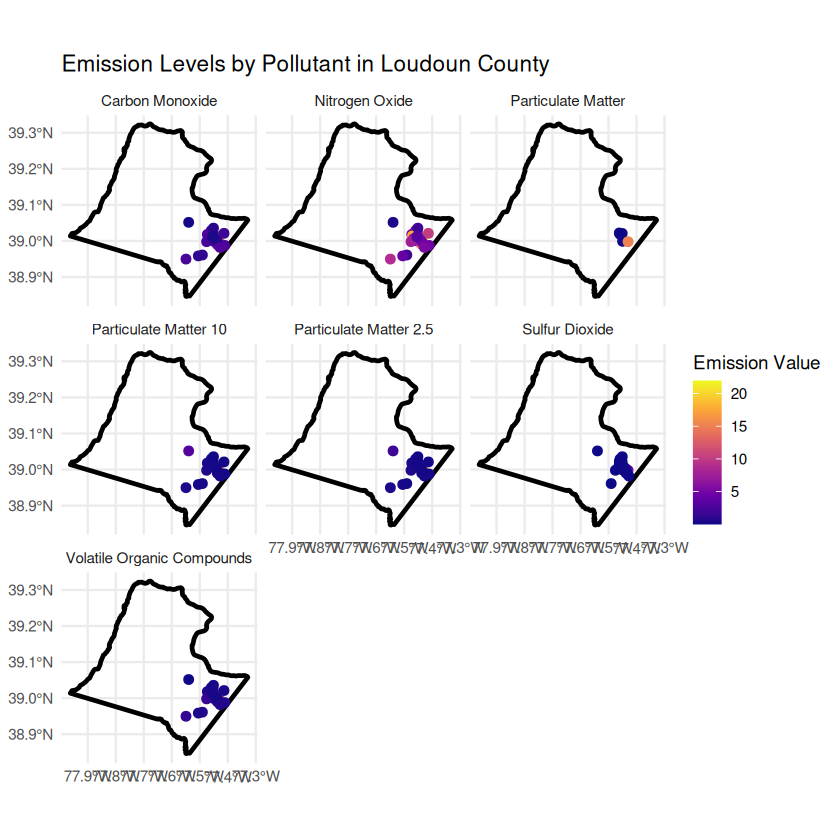

In [41]:
# plot 

#ggplot() +
  # Loudoun County outline
 # geom_sf(
 #   data = boundary,
 #   fill = NA,
 #   color = "black",
 #   linewidth = 1
  #) +
  # Emissions mapped by intensity
 # geom_sf(
 #   data = emissions_sf,
 #   aes(color = emission_value),
 #   size = 2
 # ) +
 # scale_color_viridis_c(option = "plasma") +
 # theme_minimal() +
 # labs(
 #   title = "Data Centers and Emission Levels in Loudoun County",
 #   color = "Emission Value"
 # )

ggplot() +
  geom_sf(data = boundary, fill = NA, color = "black", linewidth = 1) +
  geom_sf(
    data = emissions_sf,
    aes(color = emission_value),
    size = 2
  ) +
  facet_wrap(~ pollutant_name) +
  scale_color_viridis_c(option = "plasma") +
  theme_minimal() +
  labs(
    title = "Emission Levels by Pollutant in Loudoun County",
    color = "Emission Value"
  )

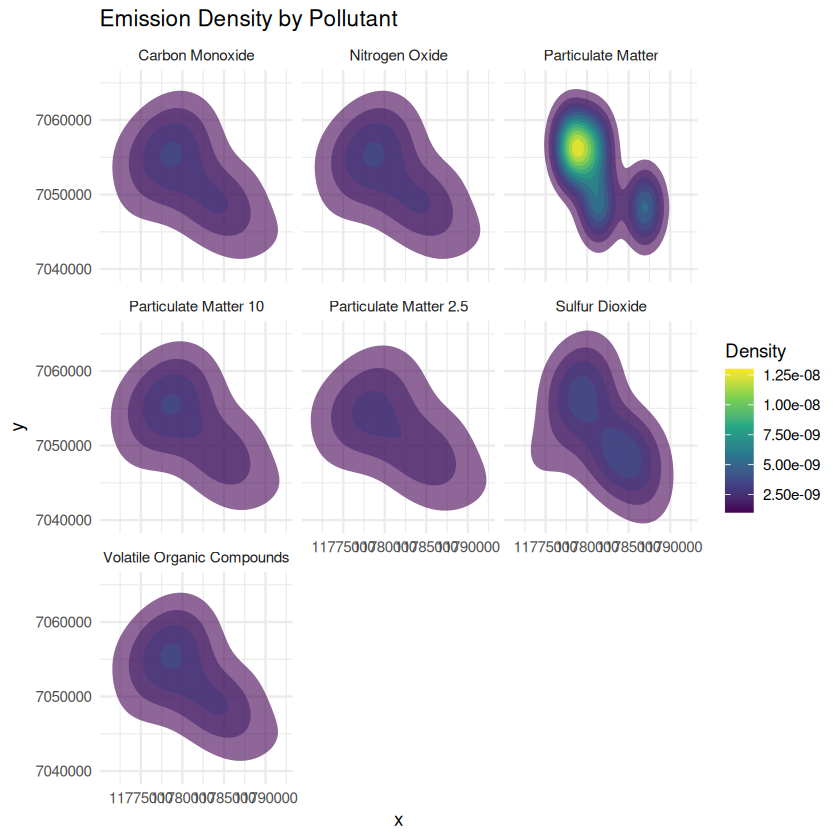

In [42]:
# Create a heat map by pollutant

# project to planar CRS
emissions_projected <- st_transform(emissions_sf, 2283)  # Virginia State Plane

coords <- st_coordinates(emissions_projected)

emissions_projected <- emissions_projected %>%
  mutate(
    x = coords[,1],
    y = coords[,2]
  )

ggplot(emissions_projected) +
  stat_density_2d(
    aes(x = x, y = y, fill = after_stat(level)),
    geom = "polygon",
    alpha = 0.6
  ) +
  facet_wrap(~ pollutant_name) +
  scale_fill_viridis_c() +
  theme_minimal() +
  labs(
    title = "Emission Density by Pollutant",
    fill = "Density"
  )


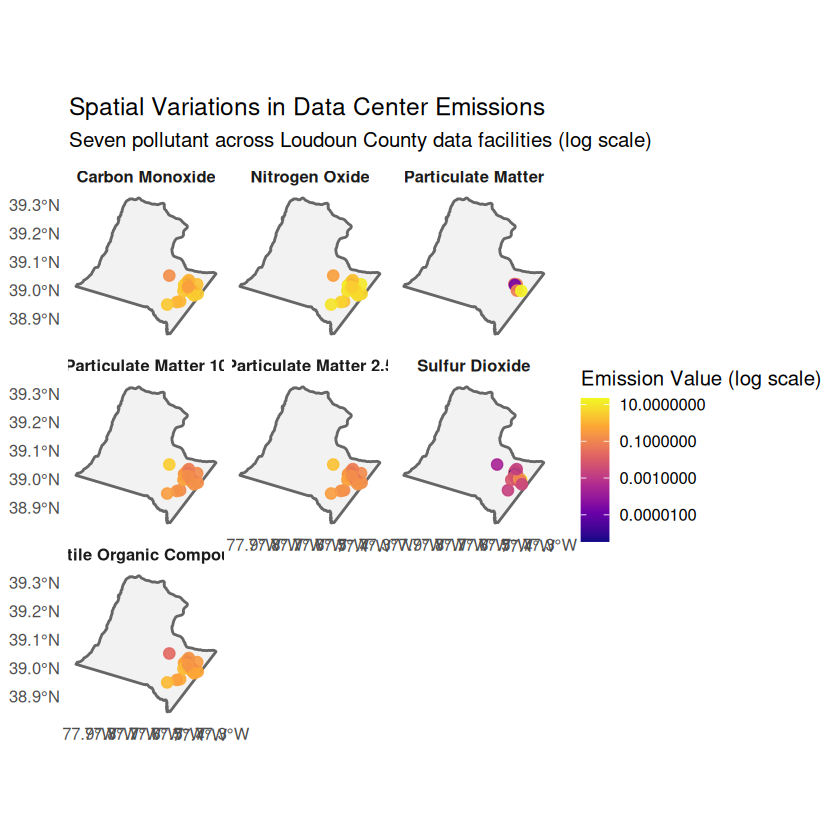

In [43]:
# Faceted Emissions Map

ggplot() +
  geom_sf(data = boundary, fill = "grey95", color = "grey40", linewidth = 0.6) +
  geom_sf(
    data = emissions_sf,
    aes(color = emission_value),
    size = 2.5,
    alpha = 0.9
  ) +
  facet_wrap(~ pollutant_name, ncol = 3) +
  scale_color_viridis_c(
    option = "plasma",
    trans = "log10",
    labels = scales::comma
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid.major = element_blank(),
    strip.text = element_text(face = "bold"),
    legend.position = "right"
  ) +
  labs(
    title = "Spatial Variations in Data Center Emissions",
    subtitle = "Seven pollutant across Loudoun County data facilities (log scale)",
    color = "Emission Value (log scale)"
  )

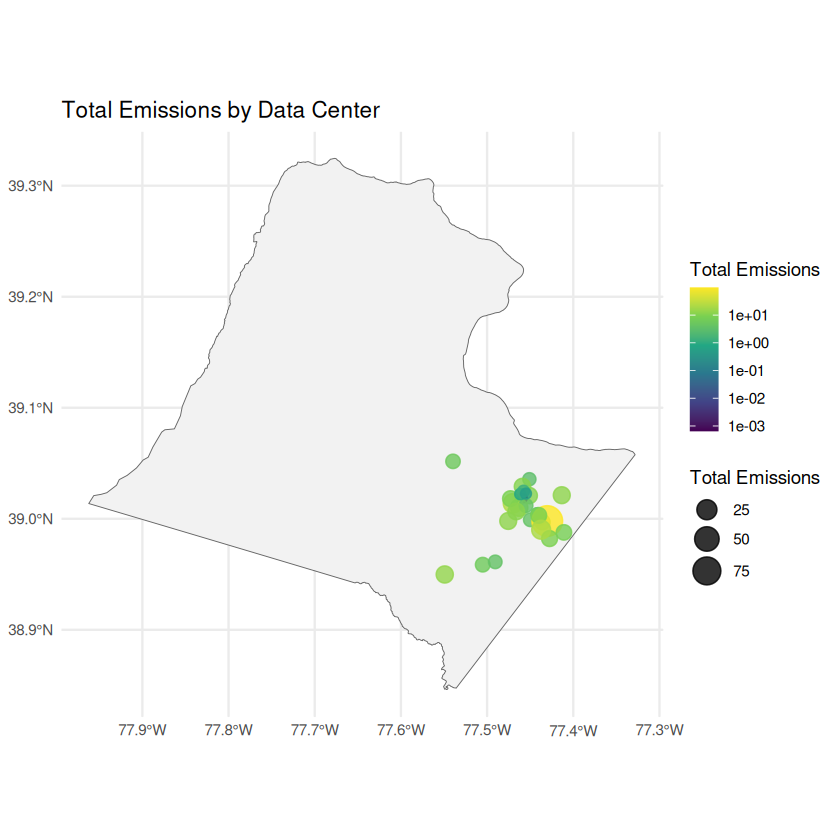

In [44]:
# Total Facility Burden Map (One Per Facility)

emissions_total <- emissions_sf %>%
  group_by(address_clean) %>%
  summarise(total_emissions = sum(emission_value, na.rm = TRUE))

ggplot() +
  geom_sf(data = boundary, fill = "grey95", color = "grey40") +
  geom_sf(
    data = emissions_total,
    aes(size = total_emissions, color = total_emissions),
    alpha = 0.8
  ) +
  scale_color_viridis_c(trans = "log10") +
  scale_size_continuous(range = c(2,8)) +
  theme_minimal() +
  labs(
    title = "Total Emissions by Data Center",
    color = "Total Emissions",
    size = "Total Emissions"
  )

In [45]:
# Investigate what percentage of air emissions comes from data centers from DEQ's air emissions database



